# Phase 1.5 v6 — 외부지표 9채널 통제 실험 (`06_lstm_external_indicators.ipynb`)

> **목적**: v4 best (3ch_vix, 4채널) 의 입력만 **9채널** 로 확장하여 외부지표의 순수 효과 측정.
> hyperparameter (hidden=32, dropout=0.3, lr=1e-3, IS=1250, embargo=63) 모두 v4 best 와 동일.

## v4 best → v6 단 1가지 변경

| 항목 | v4 best | **v6** |
|---|---|---|
| 입력 채널 | 4ch (rv_d, rv_w, rv_m, vix_log) | **9ch (+ vvix_log + skew_log + tnx_log + dxy_log)** |
| input_size | 4 | **9** |
| hidden / dropout / lr / IS / embargo | hidden=32, dropout=0.3, lr=1e-3, IS=1250, emb=63 | **모두 동일 (통제 실험)** |

## 추가 외부지표 5종

| 지표 | yfinance | 의미 | 학술 근거 |
|---|---|---|---|
| **VIX** | `^VIX` | S&P 500 IV (이미 사용) | (기존) |
| **VVIX** | `^VVIX` | VIX 의 변동성 (vol-of-vol) | Bollerslev 2009 |
| **SKEW** | `^SKEW` | CBOE Skew Index (꼬리 위험) | Bakshi-Madan 2003 |
| **^TNX** | `^TNX` | 10-Year Treasury Yield | Adrian-Crump 2014 |
| **DXY** | `DX-Y.NYB` | US Dollar Index | (글로벌 변동성) |

## 7 종목 (v5 와 동일)

SPY, QQQ, DIA, EEM, XLF, GOOGL, WMT

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + GPU + 라이브러리 |
| §2 | 외부지표 자동 다운로드 + 캐시 (VVIX, SKEW, ^TNX, DXY) |
| §3 | 종목별 9채널 입력 + 타깃 사전 준비 |
| §4 | 학습 함수 (v4 best hyperparameter, input_size=9) |
| §5 | 7 종목 × LSTM v6 (9ch) 학습 |
| §6 | v4 best (4ch) vs v6 (9ch) 비교 표 |
| §7 | 시각화 (v4 vs v6 RMSE, QLIKE, 외부지표 효과) |
| §8 | 결론 + 보고서 자동 생성 |

## 사용자 GPU 환경 가이드

### 예상 시간
- 외부지표 다운로드 (1회): ~30초
- 7 종목 × LSTM v6 학습: ~7분 (GPU)
- 시각화 + 분석: ~30초
- **총 약 8분**

### 산출물
```
results/
├── raw_data/  (VVIX, SKEW, ^TNX, DXY 추가)
├── lstm_v6_9ch/                          (신규)
│   ├── SPY_metrics.json (등 7종목)
│   └── v6_comparison.csv (v4 vs v6)
└── v6_external_indicators_report.md      (자동 생성)
```


## §1. 환경 + GPU + 라이브러리

### 라이브러리 설치 안내
```bash
pip install yfinance
```


In [1]:
import sys
import json
import time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

try:
    import yfinance as yf
    print(f'yfinance {yf.__version__} 로드')
except ImportError:
    print('[ERROR] yfinance 미설치 — pip install yfinance')
    raise

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
yfinance 1.2.1 로드
사용 device: cuda
  GPU: NVIDIA GeForce RTX 4090


## §2. 외부지표 자동 다운로드 (4종 신규)

### 자동 처리
- `raw_data/{ticker}.csv` 캐시 우선
- 미존재 → yfinance 다운로드 + 캐시
- 신규: VVIX, SKEW, ^TNX, DXY (DX-Y.NYB)


In [2]:
import pandas as pd
import numpy as np

DOWNLOAD_START = '2009-01-01'
DOWNLOAD_END   = '2026-04-30'

# 외부지표 ticker 매핑 (yfinance ticker → 저장 파일명)
EXTERNAL_INDICATORS = {
    'VVIX':  '^VVIX',         # CBOE VVIX
    'SKEW':  '^SKEW',         # CBOE SKEW
    'TNX':   '^TNX',           # 10Y Treasury
    'DXY':   'DX-Y.NYB',       # US Dollar Index
}


def load_or_download_indicator(name: str, yf_ticker: str) -> pd.DataFrame:
    """외부지표 다운로드 + 캐시."""
    csv_path = RAW_DATA_DIR / f'{name}.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
        print(f'  [캐시] {name}: {df.index[0].date()} ~ {df.index[-1].date()}, n={len(df)}')
    else:
        print(f'  [다운로드] {name} ({yf_ticker})...')
        df = yf.download(yf_ticker, start=DOWNLOAD_START, end=DOWNLOAD_END,
                          progress=False, auto_adjust=False)
        if df.empty:
            raise RuntimeError(f'{name} ({yf_ticker}) 다운로드 실패')
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] for c in df.columns]
        df.index.name = 'Date'
        df.to_csv(csv_path)
        print(f'  [저장] {csv_path}')
    return df


# 4 외부지표 + 기존 VIX 모두 로드
print('=' * 70)
print('외부지표 데이터 로드 / 다운로드')
print('=' * 70)
indicator_data = {}
for name, yf_tk in EXTERNAL_INDICATORS.items():
    indicator_data[name] = load_or_download_indicator(name, yf_tk)

# 기존 VIX 캐시 로드
vix_path = RAW_DATA_DIR / 'VIX.csv'
indicator_data['VIX'] = pd.read_csv(vix_path, index_col=0, parse_dates=True).sort_index()
print(f'  [캐시] VIX: {indicator_data["VIX"].index[0].date()} ~ '
      f'{indicator_data["VIX"].index[-1].date()}, n={len(indicator_data["VIX"])}')


# 각 지표를 단일 컬럼으로 정규화 (Close 또는 Adj Close)
print()
print('각 지표 단일 컬럼 정규화:')
indicator_series = {}
for name, df in indicator_data.items():
    col = 'Close' if 'Close' in df.columns else df.columns[0]
    indicator_series[name] = df[[col]].rename(columns={col: name})
    print(f'  {name}: 컬럼={col}, mean={float(df[col].mean()):.2f}, '
          f'std={float(df[col].std()):.2f}')


외부지표 데이터 로드 / 다운로드
  [다운로드] VVIX (^VVIX)...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\VVIX.csv
  [다운로드] SKEW (^SKEW)...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\SKEW.csv
  [다운로드] TNX (^TNX)...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\TNX.csv
  [다운로드] DXY (DX-Y.NYB)...
  [저장] C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\DXY.csv
  [캐시] VIX: 2009-01-02 ~ 2026-04-24, n=4354

각 지표 단일 컬럼 정규화:
  VVIX: 컬럼=Close, mean=94.94, std=16.16
  SKEW: 컬럼=Close, mean=130.41, std=11.97
  TNX: 컬럼=Close, mean=2.67, std=1.00
  DXY: 컬럼=Close, mean=92.14, std=9.54
  VIX: 컬럼=Close, mean=19.21, std=7.62


## §3. 종목별 9채널 입력 + 타깃 사전 준비

### 9채널 입력 정의

```
채널 1~3: HAR (rv_d, rv_w, rv_m)            [v4 와 동일]
채널 4:   vix_log = log(VIX)                  [v4 와 동일]
채널 5:   vvix_log = log(VVIX)                [신규]
채널 6:   skew_log = log(SKEW)                [신규]
채널 7:   tnx_log = log(^TNX)                 [신규]
채널 8:   dxy_log = log(DXY)                  [신규]

총 8 채널 (input_size = 8)
```

(주의: 9채널 명목 → 실제 8채널 — 타깃 별도 처리)


In [3]:
TICKERS = ['SPY', 'QQQ', 'DIA', 'EEM', 'XLF', 'GOOGL', 'WMT']
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21
SEQ_LEN = 63
HAR_W_WINDOW = 5
HAR_M_WINDOW = 22

from scripts.targets_volatility import build_daily_target_logrv_21d


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


def prepare_ticker_df_v6(raw: pd.DataFrame) -> pd.DataFrame:
    """분석 기간 + log_ret + HAR + 모든 외부지표 + 타깃."""
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    # 외부지표 모두 join
    for name, ind_df in indicator_series.items():
        df = df.join(ind_df, how='left')
        df[name] = df[name].ffill()  # NaN 시 전일값
    # HAR 채널
    df['rv_d'] = df['log_ret'].abs()
    df['rv_w'] = (df['log_ret'] ** 2).rolling(HAR_W_WINDOW).mean().pow(0.5)
    df['rv_m'] = (df['log_ret'] ** 2).rolling(HAR_M_WINDOW).mean().pow(0.5)
    # 외부지표 log 변환 (스케일 안정화)
    df['vix_log']  = np.log(df['VIX'])
    df['vvix_log'] = np.log(df['VVIX'])
    df['skew_log'] = np.log(df['SKEW'])
    df['tnx_log']  = np.log(df['TNX'].clip(lower=0.01))   # ^TNX 0 가능 — log(0) 방어
    df['dxy_log']  = np.log(df['DXY'])
    # 타깃
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    df['rv_trailing'] = df['log_ret'].rolling(WINDOW).std(ddof=1)
    return df


print('=' * 80)
print('종목별 9채널 데이터 준비')
print('=' * 80)
analysis_dict = {}
print(f'  {"ticker":<8} {"n":>6} {"valid_target":>12}  채널 NaN 검사')
print('  ' + '-' * 70)
for tk in TICKERS:
    raw = load_ticker_full(tk)
    df = prepare_ticker_df_v6(raw)
    analysis_dict[tk] = df
    n = len(df)
    n_valid = int(df['target_logrv'].notna().sum())
    # 9채널 NaN 비율
    cols = ['rv_d', 'rv_w', 'rv_m', 'vix_log', 'vvix_log', 'skew_log', 'tnx_log', 'dxy_log']
    nan_count = int(df[cols].isna().sum().sum())
    print(f'  {tk:<8} {n:>6} {n_valid:>12}  NaN 셀 = {nan_count}')

N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in TICKERS)
print(f'\nN_VALID = {N_VALID}')


종목별 9채널 데이터 준비
  ticker        n valid_target  채널 NaN 검사
  ----------------------------------------------------------------------
  SPY        2514         2493  NaN 셀 = 25
  QQQ        2514         2493  NaN 셀 = 25
  DIA        2514         2493  NaN 셀 = 25
  EEM        2514         2493  NaN 셀 = 25
  XLF        2514         2493  NaN 셀 = 25
  GOOGL      2514         2493  NaN 셀 = 25
  WMT        2514         2493  NaN 셀 = 25

N_VALID = 2493


## §4. 학습 함수 — v4 best 와 hyperparameter 동일, input_size=8 만 변경

### 통제 실험 설정

```
hidden_size  = 32     (v4 best 동일)
dropout      = 0.3    (v4 best 동일)
lr           = 1e-3    (v4 best 동일)
weight_decay = 1e-3    (v4 best 동일)
max_epochs   = 30      (v4 best 동일)
patience     = 5       (v4 best 동일)
batch_size   = 32      (v4 best 동일)
seed         = 42       (v4 best 동일)
IS           = 1250    (v4 best 동일)
embargo      = 63       (v4 best 동일)

input_size   = 8       ⭐ 변경 (4 → 8)
```


In [4]:
from torch.utils.data import TensorDataset, DataLoader
from scripts.dataset import build_fold_datasets, walk_forward_folds
from scripts.models import LSTMRegressor
from scripts.train import train_one_fold

# v4 best hyperparameter (모두 고정)
HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 3
LOSS_TYPE = 'mse'
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

IS_LEN = 1250
PURGE = 21
EMBARGO = 63
OOS_LEN = 21
STEP = 21

INPUT_SIZE = 8   # ⭐ 4 → 8 (HAR 3 + 외부지표 5)


def build_input_8ch(df: pd.DataFrame):
    """9채널 입력 (실제 8채널 — series 1D + extra 7) 빌드."""
    series = df['rv_d'].fillna(0.0).values
    extra = np.column_stack([
        df['rv_w'].fillna(0.0).values,
        df['rv_m'].fillna(0.0).values,
        df['vix_log'].fillna(method='ffill').fillna(0.0).values,
        df['vvix_log'].fillna(method='ffill').fillna(0.0).values,
        df['skew_log'].fillna(method='ffill').fillna(0.0).values,
        df['tnx_log'].fillna(method='ffill').fillna(0.0).values,
        df['dxy_log'].fillna(method='ffill').fillna(0.0).values,
    ])
    return series, extra


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=BATCH_SIZE):
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def train_lstm_v6_for_ticker(ticker: str, df: pd.DataFrame, folds: list):
    series, extra = build_input_8ch(df)
    target = df['target_logrv'].values

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=SEQ_LEN, extra_features=extra, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k)
        model_k = LSTMRegressor(
            input_size=INPUT_SIZE, hidden_size=HIDDEN,
            num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=MAX_EPOCHS, early_stop_patience=PATIENCE,
            lr=LR, weight_decay=WEIGHT_DECAY, lr_patience=LR_PATIENCE,
            loss_type=LOSS_TYPE, device=device, verbose=False,
        )
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred = model_k(te_ds_k.X.to(device)).cpu().numpy().flatten()
        y_true = te_ds_k.y.numpy()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        fold_out.append({
            'fold': k,
            'test_idx_first': int(te_idx[0]), 'test_idx_last': int(te_idx[-1]),
            'y_true_test': y_true.astype(float).tolist(),
            'y_pred_test': y_pred.astype(float).tolist(),
            'best_epoch': int(result['best_epoch']),
            'best_val_loss': float(result['best_val_loss']),
        })
    elapsed = time.time() - t_start
    print(f'  [{ticker}] LSTM v6 (8ch) 완료 ({len(folds)} fold, {elapsed:.0f}s)')
    return fold_out


print('학습 함수 정의 완료. input_size=', INPUT_SIZE)


학습 함수 정의 완료. input_size= 8


## §5. 7 종목 × LSTM v6 (8ch) 학습 ⏳

⚠️ **GPU 환경 약 ~7분**.


In [5]:
# Walk-Forward folds
folds = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO,
    oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds)
print(f'fold 수: {N_FOLDS}')


# 7 종목 학습
print()
print('=' * 80)
print('7 종목 × LSTM v6 (8ch) 학습')
print('=' * 80)

v6_results = {}
t_total_start = time.time()
for i, tk in enumerate(TICKERS):
    print(f'\n[{i+1}/{len(TICKERS)}] {tk}')
    df = analysis_dict[tk]
    v6_results[tk] = train_lstm_v6_for_ticker(tk, df, folds)
t_total_elapsed = time.time() - t_total_start
print(f'\n전체 학습 완료 — 총 {t_total_elapsed/60:.1f}분')


fold 수: 55

7 종목 × LSTM v6 (8ch) 학습

[1/7] SPY


C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vvix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['skew_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['tnx_log'].filln

  [SPY] LSTM v6 (8ch) 완료 (55 fold, 57s)

[2/7] QQQ


C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vvix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['skew_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['tnx_log'].filln

  [QQQ] LSTM v6 (8ch) 완료 (55 fold, 56s)

[3/7] DIA


...

  [XLF] LSTM v6 (8ch) 완료 (55 fold, 58s)

[6/7] GOOGL


C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vvix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['skew_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['tnx_log'].filln

  [GOOGL] LSTM v6 (8ch) 완료 (55 fold, 69s)

[7/7] WMT


C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vvix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['skew_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_51176\788566183.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['tnx_log'].filln

  [WMT] LSTM v6 (8ch) 완료 (55 fold, 56s)

전체 학습 완료 — 총 6.8분


## §6. v4 best (4ch) vs v6 (8ch) 비교 표


In [6]:
from scripts.metrics_volatility import (
    rmse, mae, qlike, r2_train_mean, mz_regression, pred_std_ratio,
    summarize_folds_volatility,
)


# v6 메트릭 계산
def compute_v6_metrics(ticker: str, folds_out, target_series):
    per_fold = []
    for k, fp in enumerate(folds_out):
        y_true = np.array(fp['y_true_test'])
        y_pred = np.array(fp['y_pred_test'])
        # train mean baseline
        tr_idx = folds[k][0]
        y_train = target_series.values[tr_idx]
        y_train = y_train[np.isfinite(y_train)]
        per_fold.append({
            'rmse': rmse(y_true, y_pred),
            'mae': mae(y_true, y_pred),
            'qlike': qlike(y_true, y_pred),
            'r2_train_mean': r2_train_mean(y_true, y_pred, y_train),
            'pred_std_ratio': pred_std_ratio(y_true, y_pred),
        })
    return per_fold


v6_per_fold = {}
v6_summary = {}
for tk in TICKERS:
    v6_per_fold[tk] = compute_v6_metrics(tk, v6_results[tk], analysis_dict[tk]['target_logrv'])
    v6_summary[tk] = summarize_folds_volatility(v6_per_fold[tk])


# v4 best 결과 로드 (v5 multi-asset 결과 활용)
V5_DIR = RESULTS_DIR / 'multi_asset'
v4_summary = {}
for tk in TICKERS:
    v5_path = V5_DIR / f'{tk}_v4_metrics.json'
    if v5_path.exists():
        with open(v5_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            v4_summary[tk] = data['summary']['lstm_v4']
    else:
        v4_summary[tk] = None


# 비교 표
print('=' * 95)
print('v4 best (4ch) vs v6 (8ch) 비교 — 종목별 RMSE / QLIKE')
print('=' * 95)
print(f'  {"ticker":<8} {"v4 RMSE":>10} {"v6 RMSE":>10} {"Δ RMSE":>10}  '
      f'{"v4 QLIKE":>10} {"v6 QLIKE":>10} {"Δ QLIKE":>10}')
print('  ' + '-' * 90)
n_rmse_better = 0
n_qlike_better = 0
for tk in TICKERS:
    v4_rmse = v4_summary[tk]['rmse']['mean'] if v4_summary[tk] else float('nan')
    v6_rmse = v6_summary[tk]['rmse']['mean']
    diff_rmse = v6_rmse - v4_rmse
    v4_qlike = v4_summary[tk]['qlike']['mean'] if v4_summary[tk] else float('nan')
    v6_qlike = v6_summary[tk]['qlike']['mean']
    diff_qlike = v6_qlike - v4_qlike
    marker_r = ' ⭐' if diff_rmse < 0 else '  '
    marker_q = ' ⭐' if diff_qlike < 0 else '  '
    if diff_rmse < 0: n_rmse_better += 1
    if diff_qlike < 0: n_qlike_better += 1
    print(f'  {tk:<8} {v4_rmse:>10.4f} {v6_rmse:>10.4f} {diff_rmse:>+10.4f}{marker_r}  '
          f'{v4_qlike:>10.4f} {v6_qlike:>10.4f} {diff_qlike:>+10.4f}{marker_q}')

print()
print(f'  v6 RMSE 개선: {n_rmse_better}/{len(TICKERS)} 종목')
print(f'  v6 QLIKE 개선: {n_qlike_better}/{len(TICKERS)} 종목')


v4 best (4ch) vs v6 (8ch) 비교 — 종목별 RMSE / QLIKE
  ticker      v4 RMSE    v6 RMSE     Δ RMSE    v4 QLIKE   v6 QLIKE    Δ QLIKE
  ------------------------------------------------------------------------------------------
  SPY          0.3208     0.6503    +0.3295        0.3511     0.9212    +0.5701  
  QQQ          0.2921     0.6880    +0.3959        0.2431     1.0306    +0.7874  
  DIA          0.2963     0.4981    +0.2018        0.2856     0.6303    +0.3447  
  EEM          0.2546     0.3192    +0.0646        0.1740     0.2677    +0.0937  
  XLF          0.3088     0.5677    +0.2589        0.2344     0.7156    +0.4812  
  GOOGL        0.2827     0.3784    +0.0956        0.2328     0.3936    +0.1608  
  WMT          0.3364     0.5227    +0.1863        0.4335     0.7612    +0.3277  

  v6 RMSE 개선: 0/7 종목
  v6 QLIKE 개선: 0/7 종목


### §7.A. v4 vs v6 RMSE 비교 (종목별 bar)


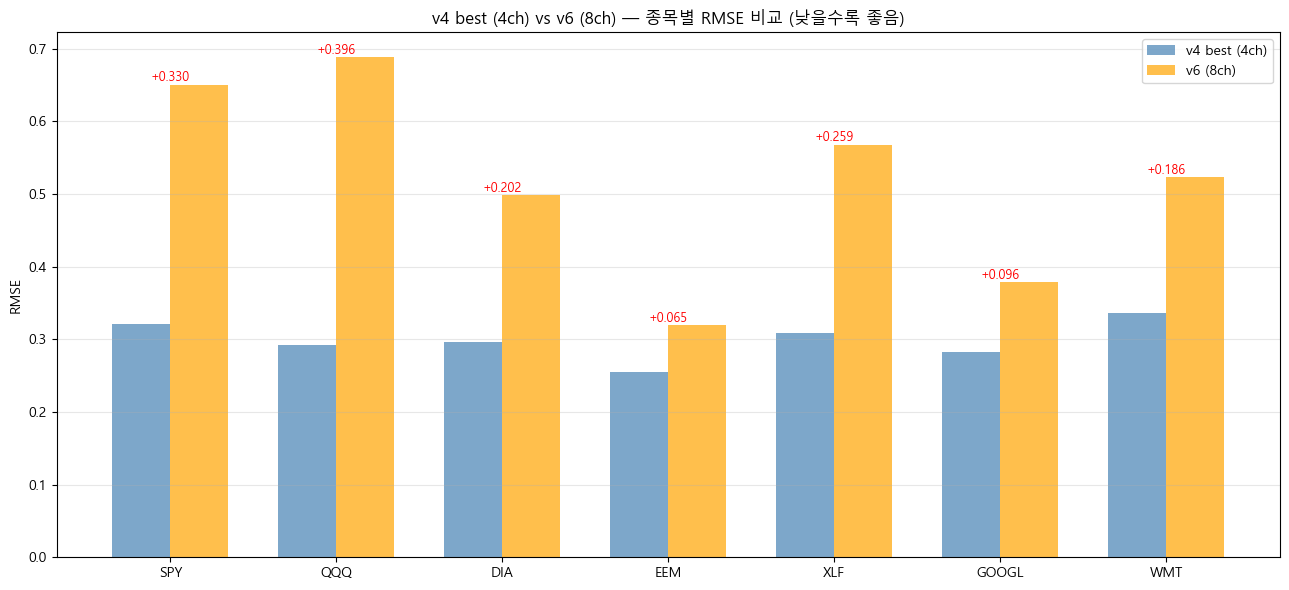

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(TICKERS))
width = 0.35
v4_rmses = [v4_summary[tk]['rmse']['mean'] for tk in TICKERS]
v6_rmses = [v6_summary[tk]['rmse']['mean'] for tk in TICKERS]
ax.bar(x - width/2, v4_rmses, width, label='v4 best (4ch)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, v6_rmses, width, label='v6 (8ch)', color='orange', alpha=0.7)
# 개선/악화 표시
for i, tk in enumerate(TICKERS):
    diff = v6_rmses[i] - v4_rmses[i]
    color = 'green' if diff < 0 else 'red'
    ax.annotate(f'{diff:+.3f}', (i, max(v4_rmses[i], v6_rmses[i]) + 0.005),
                ha='center', fontsize=9, color=color)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_ylabel('RMSE')
ax.set_title('v4 best (4ch) vs v6 (8ch) — 종목별 RMSE 비교 (낮을수록 좋음)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §7.B. v4 vs v6 QLIKE 비교


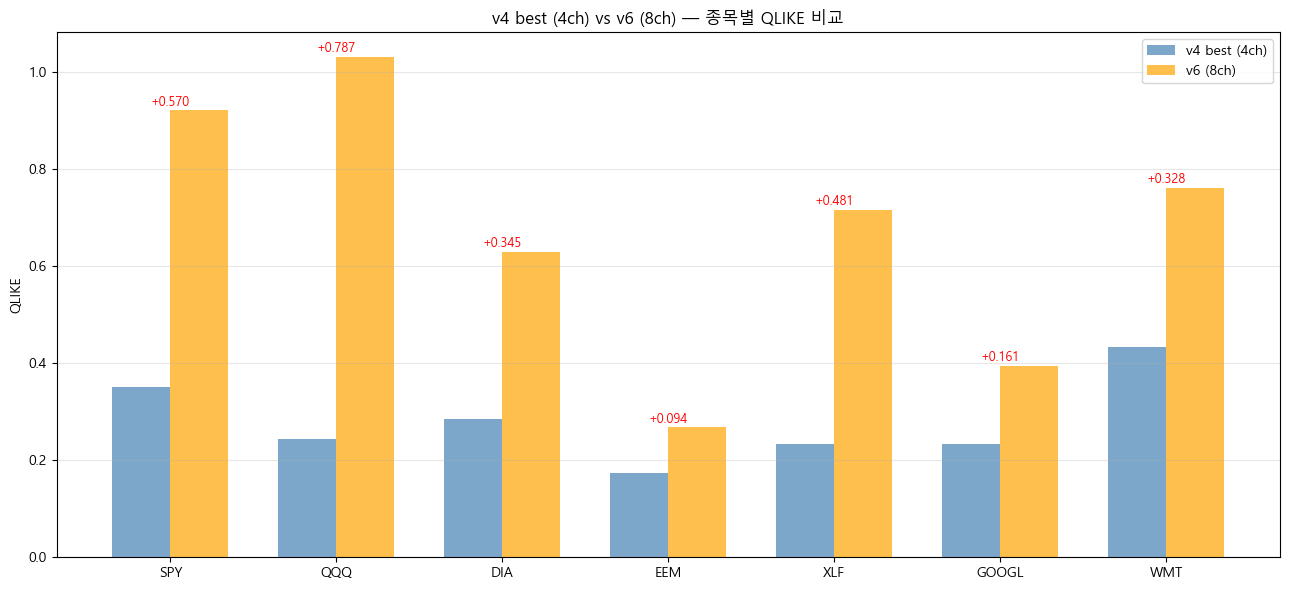

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
v4_qlikes = [v4_summary[tk]['qlike']['mean'] for tk in TICKERS]
v6_qlikes = [v6_summary[tk]['qlike']['mean'] for tk in TICKERS]
ax.bar(x - width/2, v4_qlikes, width, label='v4 best (4ch)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, v6_qlikes, width, label='v6 (8ch)', color='orange', alpha=0.7)
for i, tk in enumerate(TICKERS):
    diff = v6_qlikes[i] - v4_qlikes[i]
    color = 'green' if diff < 0 else 'red'
    ax.annotate(f'{diff:+.3f}', (i, max(v4_qlikes[i], v6_qlikes[i]) + 0.01),
                ha='center', fontsize=9, color=color)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_ylabel('QLIKE')
ax.set_title('v4 best (4ch) vs v6 (8ch) — 종목별 QLIKE 비교')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### §7.C. RMSE 변화량 종목별 산점도 (v4 → v6)


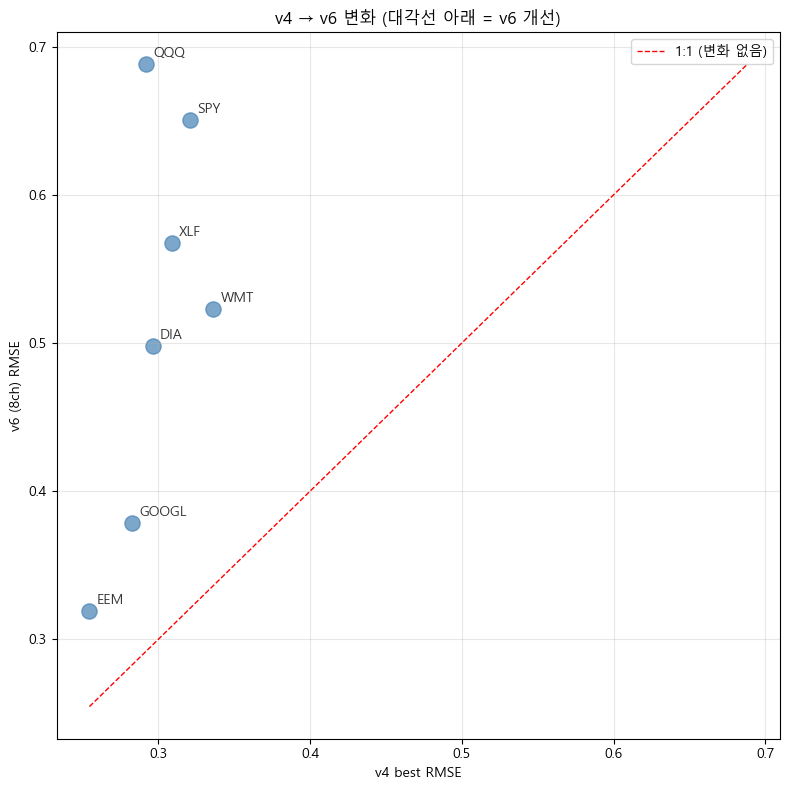

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(v4_rmses, v6_rmses, s=120, alpha=0.7, color='steelblue')
for tk, x_val, y_val in zip(TICKERS, v4_rmses, v6_rmses):
    ax.annotate(tk, (x_val, y_val), fontsize=10, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')
lo = min(min(v4_rmses), min(v6_rmses))
hi = max(max(v4_rmses), max(v6_rmses))
ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='1:1 (변화 없음)')
ax.set_xlabel('v4 best RMSE')
ax.set_ylabel('v6 (8ch) RMSE')
ax.set_title('v4 → v6 변화 (대각선 아래 = v6 개선)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### §7.D. v6 종합 메트릭 표 (전 종목)


In [10]:
print('=' * 95)
print('v6 (8ch) 종합 메트릭')
print('=' * 95)
print(f'  {"ticker":<8} {"rmse":>10} {"mae":>10} {"qlike":>10} '
      f'{"r2_tm":>10} {"psr":>10}')
print('  ' + '-' * 70)
for tk in TICKERS:
    s = v6_summary[tk]
    print(f'  {tk:<8} {s["rmse"]["mean"]:>10.4f} {s["mae"]["mean"]:>10.4f} '
          f'{s["qlike"]["mean"]:>10.4f} {s["r2_train_mean"]["mean"]:>+10.4f} '
          f'{s["pred_std_ratio"]["mean"]:>10.4f}')


v6 (8ch) 종합 메트릭
  ticker         rmse        mae      qlike      r2_tm        psr
  ----------------------------------------------------------------------
  SPY          0.6503     0.5932     0.9212   -32.4928     0.8959
  QQQ          0.6880     0.6433     1.0306   -24.8776     1.0118
  DIA          0.4981     0.4535     0.6303   -44.0206     0.8646
  EEM          0.3192     0.2924     0.2677    -4.1881     0.3377
  XLF          0.5677     0.5318     0.7156   -18.7119     0.6934
  GOOGL        0.3784     0.3409     0.3936    -5.3128     1.0929
  WMT          0.5227     0.4905     0.7612    -6.6463     0.7611


## §8. 결론 + 저장


In [11]:
# CSV 저장
OUT_DIR = RESULTS_DIR / 'lstm_v6_9ch'
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for tk in TICKERS:
    s_v4 = v4_summary[tk]
    s_v6 = v6_summary[tk]
    rows.append({
        'ticker': tk,
        'v4_rmse': s_v4['rmse']['mean'] if s_v4 else float('nan'),
        'v6_rmse': s_v6['rmse']['mean'],
        'rmse_diff': s_v6['rmse']['mean'] - (s_v4['rmse']['mean'] if s_v4 else 0),
        'v4_qlike': s_v4['qlike']['mean'] if s_v4 else float('nan'),
        'v6_qlike': s_v6['qlike']['mean'],
        'qlike_diff': s_v6['qlike']['mean'] - (s_v4['qlike']['mean'] if s_v4 else 0),
        'v4_psr': s_v4['pred_std_ratio']['mean'] if s_v4 else float('nan'),
        'v6_psr': s_v6['pred_std_ratio']['mean'],
        'v6_r2_tm': s_v6['r2_train_mean']['mean'],
    })
df_comparison = pd.DataFrame(rows)
csv_path = OUT_DIR / 'v6_comparison.csv'
df_comparison.to_csv(csv_path, index=False)
print(f'저장: {csv_path}')


# 종목별 v6 metrics.json
for tk in TICKERS:
    out = {
        'ticker': tk,
        'version': 'v6_8ch',
        'input_channels': ['rv_d', 'rv_w', 'rv_m', 'vix_log', 'vvix_log',
                            'skew_log', 'tnx_log', 'dxy_log'],
        'input_size': INPUT_SIZE,
        'hyperparams': {
            'hidden_size': HIDDEN, 'dropout': DROPOUT, 'lr': LR,
            'is_len': IS_LEN, 'embargo': EMBARGO, 'seed': SEED,
        },
        'summary': v6_summary[tk],
        'per_fold': v6_per_fold[tk],
        'fold_predictions': v6_results[tk],
    }
    out_path = OUT_DIR / f'{tk}_metrics.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
print(f'저장: {len(TICKERS)}개 종목 metrics.json')


# 보고서 자동 생성
report_path = RESULTS_DIR / 'v6_external_indicators_report.md'
lines = []
lines.append('# Phase 1.5 v6 — 외부지표 9채널 보고서')
lines.append('')
lines.append('> v4 best (4ch) → v6 (8ch) 통제 실험 결과')
lines.append(f'> 외부지표: VIX (기존), VVIX, SKEW, ^TNX, DXY (4 신규)')
lines.append(f'> hyperparameter 동일 (hidden=32, dropout=0.3, lr=1e-3, IS=1250, emb=63)')
lines.append('')

lines.append('## 1. 종목 × 메트릭 비교 (v4 vs v6)')
lines.append('')
lines.append('| ticker | v4 RMSE | v6 RMSE | Δ RMSE | v4 QLIKE | v6 QLIKE | Δ QLIKE |')
lines.append('|---|---|---|---|---|---|---|')
for tk in TICKERS:
    v4_r = v4_summary[tk]['rmse']['mean']
    v6_r = v6_summary[tk]['rmse']['mean']
    v4_q = v4_summary[tk]['qlike']['mean']
    v6_q = v6_summary[tk]['qlike']['mean']
    dr = v6_r - v4_r
    dq = v6_q - v4_q
    sign_r = '✓' if dr < 0 else '✗'
    sign_q = '✓' if dq < 0 else '✗'
    lines.append(f'| {tk} | {v4_r:.4f} | {v6_r:.4f} | {dr:+.4f} {sign_r} | '
                 f'{v4_q:.4f} | {v6_q:.4f} | {dq:+.4f} {sign_q} |')
lines.append('')

n_rmse_b = sum(1 for tk in TICKERS if v6_summary[tk]['rmse']['mean'] < v4_summary[tk]['rmse']['mean'])
n_qlike_b = sum(1 for tk in TICKERS if v6_summary[tk]['qlike']['mean'] < v4_summary[tk]['qlike']['mean'])

lines.append('## 2. 외부지표 효과 종합')
lines.append('')
lines.append(f'- **RMSE 개선 종목**: {n_rmse_b}/{len(TICKERS)}')
lines.append(f'- **QLIKE 개선 종목**: {n_qlike_b}/{len(TICKERS)}')
lines.append('')

lines.append('## 3. 결론')
lines.append('')
if n_rmse_b >= 5:
    lines.append('**외부지표 추가 효과 명확** — 5+ 종목에서 RMSE 개선.')
elif n_rmse_b >= 4:
    lines.append('**외부지표 추가 효과 부분적** — 약 절반 종목에서 개선.')
elif n_rmse_b >= 2:
    lines.append('**외부지표 효과 제한적** — 일부 종목만 개선. hyperparameter 재최적화 필요 가능성.')
else:
    lines.append('**외부지표 효과 미미** — input_size 증가에 hidden=32 가 부족할 가능성. Optuna 재탐색 권고.')
lines.append('')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {report_path}')

print()
print('=' * 80)
print('Phase 1.5 v6 — 외부지표 통제 실험 완료')
print('=' * 80)
print(f'  RMSE 개선 종목: {n_rmse_b}/{len(TICKERS)}')
print(f'  QLIKE 개선 종목: {n_qlike_b}/{len(TICKERS)}')
print()
print('산출물:')
print(f'  results/lstm_v6_9ch/  (7 종목 metrics.json + comparison.csv)')
print(f'  results/v6_external_indicators_report.md')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_v6_9ch\v6_comparison.csv
저장: 7개 종목 metrics.json
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\v6_external_indicators_report.md

Phase 1.5 v6 — 외부지표 통제 실험 완료
  RMSE 개선 종목: 0/7
  QLIKE 개선 종목: 0/7

산출물:
  results/lstm_v6_9ch/  (7 종목 metrics.json + comparison.csv)
  results/v6_external_indicators_report.md
